In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier

## Demo: detenerse al encontrar un buen score y medir si puede explicarse por azar

Objetivo:
1. Buscar combinaciones de columnas + hiperparámetros con `RandomizedSearchCV`.
2. Detener la búsqueda al alcanzar un score objetivo (0.70) en validación.
3. Repetir el mismo procedimiento con target permutado.
4. Visualizar el histograma de mejores scores bajo azar e incluir:
   - línea vertical del score alcanzado en el experimento real,
   - p-valor empírico $P(Score_{perm} \ge Score_{real})$.

In [2]:
import itertools
from sklearn.datasets import make_classification
from sklearn.metrics import balanced_accuracy_score

# 1) Dataset: señal moderadamente debil + mucho ruido para favorecer scores cercanos al umbral.
X_signal, y = make_classification(
    n_samples=240,
    n_features=6,
    n_informative=1,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    weights=[0.82, 0.18],
    class_sep=0.40,
    flip_y=0.20,
    shuffle=True,
    random_state=42,
)

rng = np.random.RandomState(123)
X_noise = rng.normal(size=(X_signal.shape[0], 54))
X = np.hstack([X_signal, X_noise])

feature_names = [f"x{i}" for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)

# Pool muy amplio (mezcla de señal y ruido) para potenciar el vast search effect.
search_pool = [f"x{i}" for i in range(0, 48)]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_df, y, test_size=0.40, stratify=y, random_state=7
)

print(f"Muestras train/valid: {X_train.shape[0]}/{X_valid.shape[0]}")
print(f"Positivos train/valid: {int(y_train.sum())}/{int(y_valid.sum())}")
print(f"Columnas totales: {X_df.shape[1]} | Pool usado: {len(search_pool)}")


def random_search_until_threshold(
    X_train,
    y_train,
    X_valid,
    y_valid,
    candidate_features,
    score_threshold=0.70,
    n_feature_sets=120,
    subset_size_range=(2, 12),
    n_iter_model=8,
    cv_folds=3,
    stop_on_threshold=True,
    score_name="balanced_accuracy",
    random_state=0,
):
    """Explora subconjuntos aleatorios + RandomizedSearchCV y puede cortar al superar un umbral."""

    rng_local = np.random.RandomState(random_state)

    # Grid intencionalmente "conservador" para evitar scores extremos por capacidad de modelo.
    param_dist = {
        "n_estimators": [15, 25, 35, 50],
        "max_depth": [1, 2, 3],
        "min_samples_split": [10, 16, 24],
        "min_samples_leaf": [6, 10, 14],
        "max_features": ["sqrt", 0.2, 0.35],
        "class_weight": [None, "balanced"],
        "bootstrap": [True],
    }

    all_scores = []
    evaluated_subsets = []

    best_score = -np.inf
    best_config = None

    threshold_score = None
    threshold_config = None

    for attempt in range(n_feature_sets):
        subset_size = rng_local.randint(subset_size_range[0], subset_size_range[1] + 1)
        subset = tuple(sorted(rng_local.choice(candidate_features, size=subset_size, replace=False)))

        model = RandomForestClassifier(random_state=0, n_jobs=-1)
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_dist,
            n_iter=n_iter_model,
            scoring=score_name,
            cv=cv_folds,
            random_state=rng_local.randint(1_000_000),
            n_jobs=-1,
        )

        search.fit(X_train[list(subset)], y_train)
        y_pred = search.best_estimator_.predict(X_valid[list(subset)])
        score = balanced_accuracy_score(y_valid, y_pred)

        all_scores.append(score)
        evaluated_subsets.append(subset)

        if score > best_score:
            best_score = score
            best_config = {
                "subset": subset,
                f"cv_best_{score_name}": search.best_score_,
                **search.best_params_,
                "attempt": attempt + 1,
            }

        if threshold_score is None and score >= score_threshold:
            threshold_score = score
            threshold_config = {
                "subset": subset,
                f"cv_best_{score_name}": search.best_score_,
                **search.best_params_,
                "attempt": attempt + 1,
            }
            if stop_on_threshold:
                break

    if threshold_score is None:
        threshold_score = best_score
        threshold_config = best_config

    return {
        "best_score": best_score,
        "best_config": best_config,
        "threshold_score": threshold_score,
        "threshold_config": threshold_config,
        "all_scores": np.array(all_scores),
        "evaluated_subsets": evaluated_subsets,
        "evaluations": len(all_scores),
        "hit_threshold": threshold_score >= score_threshold,
        "score_name": score_name,
    }

Muestras train/valid: 144/96
Positivos train/valid: 38/25
Columnas totales: 60 | Pool usado: 48


In [3]:
# 2) Búsqueda en target real con corte al alcanzar score >= 0.70
target_score = 0.70

real_result = random_search_until_threshold(
    X_train,
    y_train,
    X_valid,
    y_valid,
    candidate_features=search_pool,
    score_threshold=target_score,
    n_feature_sets=120,
    subset_size_range=(2, 12),
    n_iter_model=8,
    cv_folds=3,
    stop_on_threshold=True,
    random_state=2026,
)

print("=== Resultado en target real ===")
print(f"Métrica: {real_result['score_name']}")
print(f"Se alcanzó umbral {target_score:.2f}: {real_result['hit_threshold']}")
print(f"Score al detener la búsqueda: {real_result['threshold_score']:.4f}")
print(f"Mejor score observado: {real_result['best_score']:.4f}")
print(f"Evaluaciones realizadas hasta el corte: {real_result['evaluations']}")
print(f"Configuración al corte: {real_result['threshold_config']}")

# Este score es la referencia para el test de permutación y la línea vertical en el histograma.
score_real_ref = real_result["threshold_score"]

=== Resultado en target real ===
Métrica: balanced_accuracy
Se alcanzó umbral 0.70: True
Score al detener la búsqueda: 0.7589
Mejor score observado: 0.7589
Evaluaciones realizadas hasta el corte: 4
Configuración al corte: {'subset': ('x10', 'x2', 'x26', 'x46'), 'cv_best_balanced_accuracy': 0.6647130647130647, 'n_estimators': 25, 'min_samples_split': 24, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 3, 'class_weight': None, 'bootstrap': True, 'attempt': 4}


In [4]:
# 3) Prueba de permutación del target repitiendo exactamente el mismo esquema de búsqueda.
n_permutations = 70
perm_best_scores = []
perm_threshold_scores = []
perm_hits_target = []

rng_perm = np.random.RandomState(999)

print("\n=== Ejecutando permutaciones de target ===")
for i in range(n_permutations):
    y_train_perm = rng_perm.permutation(y_train)
    y_valid_perm = rng_perm.permutation(y_valid)

    perm_result = random_search_until_threshold(
        X_train,
        y_train_perm,
        X_valid,
        y_valid_perm,
        candidate_features=search_pool,
        score_threshold=target_score,
        n_feature_sets=120,
        subset_size_range=(2, 12),
        n_iter_model=8,
        cv_folds=3,
        stop_on_threshold=True,
        random_state=10_000 + i,
    )

    perm_best_scores.append(perm_result["best_score"])
    perm_threshold_scores.append(perm_result["threshold_score"])
    perm_hits_target.append(perm_result["hit_threshold"])

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{n_permutations} completadas")

perm_best_scores = np.array(perm_best_scores)
perm_threshold_scores = np.array(perm_threshold_scores)
perm_hits_target = np.array(perm_hits_target, dtype=bool)

# p-valor empírico: probabilidad de observar por azar un score >= score real alcanzado.
n_exceed = np.sum(perm_best_scores >= score_real_ref)
p_value_empirico = (1 + n_exceed) / (n_permutations + 1)

print("\n=== Resultado con target permutado ===")
print(f"Permutaciones ejecutadas: {n_permutations}")
print(f"Score real alcanzado (línea vertical): {score_real_ref:.4f}")
print(f"Permutaciones con score >= score real: {n_exceed}/{n_permutations}")
print(f"p-valor empírico: {p_value_empirico:.4f}")
print(f"Promedio best_score (perm): {perm_best_scores.mean():.4f}")
print(f"Percentil 90 best_score (perm): {np.percentile(perm_best_scores, 90):.4f}")
print(f"Hits del umbral {target_score:.2f} en permutado: {perm_hits_target.mean():.2%}")


=== Ejecutando permutaciones de target ===


  10/70 completadas
  20/70 completadas
  30/70 completadas
  40/70 completadas
  50/70 completadas
  60/70 completadas
  70/70 completadas

=== Resultado con target permutado ===
Permutaciones ejecutadas: 70
Score real alcanzado (línea vertical): 0.7589
Permutaciones con score >= score real: 0/70
p-valor empírico: 0.0141
Promedio best_score (perm): 0.6224
Percentil 90 best_score (perm): 0.6529
Hits del umbral 0.70 en permutado: 2.86%


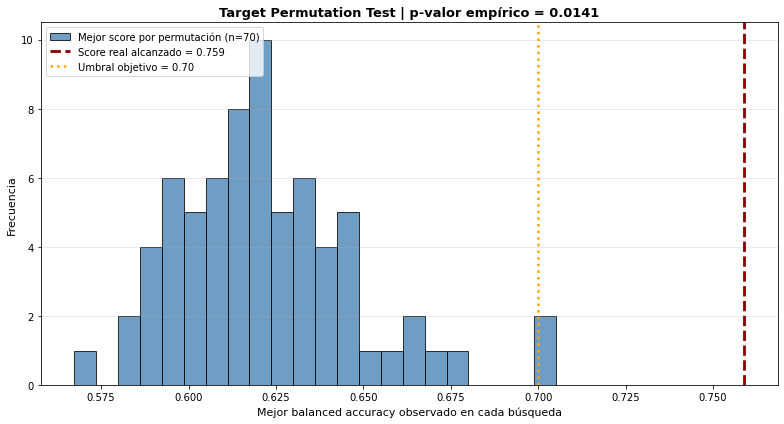

In [5]:
# 4) Histograma de mejores scores bajo azar + línea vertical del score real alcanzado.
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    perm_best_scores,
    bins=22,
    color="steelblue",
    edgecolor="black",
    alpha=0.78,
    label=f"Mejor score por permutación (n={n_permutations})",
)

ax.axvline(
    score_real_ref,
    color="darkred",
    linestyle="--",
    linewidth=2.8,
    label=f"Score real alcanzado = {score_real_ref:.3f}",
)

ax.axvline(
    target_score,
    color="orange",
    linestyle=":",
    linewidth=2.5,
    label=f"Umbral objetivo = {target_score:.2f}",
)

ax.set_title(
    f"Target Permutation Test | p-valor empírico = {p_value_empirico:.4f}",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Mejor balanced accuracy observado en cada búsqueda", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.grid(alpha=0.30, axis="y")
ax.legend(fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()